# TCC Nicolas — Análise Geoespacial da Planície de Inundação do Rio Gravataí

Notebook com todo o processamento geoespacial usado no capítulo de resultados do TCC. Reúne a coleta de dados, as sobreposições espaciais e a geração das figuras finais.

**Reprodutibilidade:** todos os dados de entrada são buscados automaticamente pela internet (IBGE, MapBiomas, CPRM, Zenodo) — não é preciso ter nenhum arquivo pré-salvo. Qualquer pessoa com uma conta Google consegue rodar este notebook do zero.

**Como usar:** `Ambiente de execução > Executar tudo` sempre que abrir numa sessão nova (a sessão do Colab reseta por inatividade, mas o código de cada célula fica salvo). Ao final, o notebook salva automaticamente uma cópia dos resultados no Google Drive de quem estiver rodando (Etapa 8), então mesmo que a sessão caia no meio do caminho, nada se perde — mas isso é só um backup pessoal, não é necessário pra reproduzir a análise em si.

O código-fonte completo também está disponível em: [LINK_GITHUB_A_INSERIR]


## Etapa 0 — Bibliotecas, importações e Drive (opcional)

Instalo e importo as bibliotecas do notebook: `geopandas` e `shapely` para os dados vetoriais, `geobr` para as malhas territoriais do IBGE, `rasterio` para os rasters do MapBiomas, e `matplotlib` para os mapas finais.

Fixei `EPSG:31982` (SIRGAS 2000 / UTM zona 22S) como projeção métrica padrão — é a projeção adequada pra calcular área no RS, já que os dados brutos chegam em coordenadas geográficas (graus), que não servem pra isso.

Tento montar o Google Drive dentro de um `try/except`: se a pessoa autorizar, os resultados são salvos automaticamente no final (Etapa 8); se recusar ou pular, a variável `DRIVE_DISPONIVEL` fica `False` e o notebook segue normalmente, só sem gravar a cópia de backup. Isso evita que o Drive seja um obstáculo pra quem só quer rodar a análise e ver as figuras.

In [ ]:
!pip install geopandas geobr matplotlib shapely rasterio --quiet

import os
import shutil
import geobr
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.mask import mask
from rasterio.features import shapes
from shapely.geometry import shape as shapely_shape
from matplotlib.patches import Patch
import numpy as np

CRS_METRICO = "EPSG:31982"  # SIRGAS 2000 / UTM zone 22S — bom para RS

# O Drive é usado só pra guardar uma cópia de backup dos resultados (Etapa 8).
# Se a pessoa rodando o notebook recusar ou pular a autorização, a análise
# continua normalmente — só a etapa de salvar cópia no Drive é pulada.
DRIVE_DISPONIVEL = False
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PASTA_DADOS = "/content/drive/MyDrive/TCC_Gravatai_Dados"
    PASTA_RESULTADOS = f"{PASTA_DADOS}/resultados"
    os.makedirs(PASTA_RESULTADOS, exist_ok=True)
    DRIVE_DISPONIVEL = True
    print("Drive montado. Resultados serão salvos em:", PASTA_RESULTADOS)
except Exception as e:
    print("Drive não conectado (ok, é opcional) — os resultados ficam só nesta sessão do Colab.")
    print("Detalhe:", e)


## Etapa 1 — Limite do município de Gravataí

Baixo o polígono oficial do município direto do IBGE, usando `read_municipality` do `geobr` (código 4309209). Reprojeto pra métrica porque é sobre essa versão que calculo a área — os 467,81 km² batem com o valor oficial do IBGE (~468 km²), o que confirma que a reprojeção e o recorte estão corretos.

Guardo também uma versão em EPSG:4326 (`geom_gravatai`), porque a função de recorte de raster que uso mais adiante (`rasterio.mask`) exige coordenadas geográficas, não métricas.

In [5]:
gravatai = geobr.read_municipality(code_muni=4309209, year=2022)
gravatai_m = gravatai.to_crs(CRS_METRICO)
gravatai_4326 = gravatai.to_crs("EPSG:4326")
geom_gravatai = [gravatai_4326.geometry.iloc[0]]

area_municipio_km2 = round(gravatai_m.area.sum() / 1_000_000, 2)
print(f"Área do município de Gravataí: {area_municipio_km2} km²")


/usr/local/lib/python3.13/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'github.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'release-assets.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
municipalities_2022_simplified.parquet: 100%|██████████| 20.6M/20.6M [00:00<00:00, 66.1MB/s]

Área do município de Gravataí: 467.81 km²


## Etapa 2 — Suscetibilidade a inundação (CPRM)

Baixo o `sig_gravatai_rs_suscet.zip` direto do repositório da CPRM via `wget` — no início eu tinha baixado esse arquivo manualmente e deixado salvo no meu Drive, mas troquei pelo link direto do bitstream assim que descobri ele, pra deixar o notebook reproduzível por qualquer pessoa.

O `geopandas` lê geopackages de dentro de um `.zip` direto, com o prefixo `zip://`, sem precisar descompactar. Dentro desse pacote tem duas camadas; uso só a `Inundacao_A` (a outra é sobre movimentos de massa, fora do escopo do trabalho).

A carta vem em três níveis (Alta, Média, Baixa). Optei por somar as três — inclusive a Baixa, que pelo método HAND ainda é várzea — porque o objetivo é mapear a planície suscetível como um todo, não hierarquizar o risco dentro dela. Recorto pro limite do município em seguida, senão ficaria com a suscetibilidade de uma área maior do que a carta cobre.

In [ ]:
caminho_zip_cprm = "/content/sig_gravatai_rs_suscet.zip"

# Verifico não só se o arquivo existe, mas se ele tem um tamanho mínimo esperado —
# um download que falhou no meio do caminho deixa um arquivo pequeno/corrompido,
# e só checar "existe" não pega esse caso.
TAMANHO_MINIMO_CPRM = 100_000  # bytes (~100 KB; o arquivo real tem alguns MB)
if not os.path.exists(caminho_zip_cprm) or os.path.getsize(caminho_zip_cprm) < TAMANHO_MINIMO_CPRM:
    print("Baixando carta de suscetibilidade da CPRM...")
    !wget -q https://rigeo.sgb.gov.br/bitstreams/af450eb5-33db-4f96-aa35-80642e1374e9/download -O {caminho_zip_cprm}
    print("Download concluído.")
else:
    print("Arquivo já baixado nesta sessão, pulando o download.")

suscetibilidade_cprm = gpd.read_file(
    f"zip://{caminho_zip_cprm}!sig_gravatai_rs_suscet/suscetibilidade.gpkg",
    layer="Inundacao_A"
)
suscetibilidade_cprm_m = suscetibilidade_cprm.to_crs(CRS_METRICO)
suscetibilidade_recortada = gpd.clip(suscetibilidade_cprm_m, gravatai_m)

area_suscetibilidade_km2 = round(suscetibilidade_recortada.area.sum() / 1_000_000, 3)
print(f"Área suscetível a inundação em Gravataí (3 classes CPRM combinadas): {area_suscetibilidade_km2} km²")
print(f"Isso equivale a {round(100 * area_suscetibilidade_km2 / area_municipio_km2, 1)}% do município")


## Etapa 3 — Uso do solo urbano em 2009 e 2024 (MapBiomas)

Essa etapa me deu mais trabalho pra descobrir a abordagem certa. No início tentei baixar os dados direto da plataforma MapBiomas em CSV, mas isso só traz números agregados, sem geometria — não dá pra fazer sobreposição espacial com isso.

A solução foi ler o raster (GeoTIFF) da Coleção 10 direto da nuvem, com o prefixo `/vsicurl/` do GDAL — o `rasterio` baixa só o pedaço da imagem que corresponde a Gravataí, sem precisar do arquivo do Brasil inteiro.

A função `extrair_area_urbana` recorta o raster pro município, filtra os pixels de valor 24 (classe "Área Urbanizada", estável entre as Coleções 8 e 11) e vetoriza — transforma a grade em polígonos, que aí cruzam com as outras camadas. Rodo duas vezes, 2009 e 2024; os resultados (46,87 km² e 56,53 km²) ficam em `gdf_urbano_2009_m` e `gdf_urbano_2024_m`.

In [7]:
def extrair_area_urbana(ano, geom_recorte_4326, crs_metrico):
    """Baixa o raster MapBiomas do ano informado, recorta pra Gravataí,
    filtra pixels de área urbana (valor 24) e devolve um GeoDataFrame na projeção métrica."""
    url = (f"/vsicurl/https://storage.googleapis.com/mapbiomas-public/initiatives/brasil/"
           f"collection_10/lulc/coverage/brazil_coverage_{ano}.tif")
    with rasterio.open(url) as src:
        out_image, out_transform = mask(src, geom_recorte_4326, crop=True)

    mask_urbano = (out_image[0] == 24)
    resultados = shapes(mask_urbano.astype("uint8"), mask=mask_urbano, transform=out_transform)
    geoms = [shapely_shape(geom) for geom, val in resultados]
    gdf = gpd.GeoDataFrame(geometry=geoms, crs="EPSG:4326")
    return gdf.to_crs(crs_metrico)

gdf_urbano_2009_m = extrair_area_urbana(2009, geom_gravatai, CRS_METRICO)
gdf_urbano_2024_m = extrair_area_urbana(2024, geom_gravatai, CRS_METRICO)

area_urbana_2009_km2 = round(gdf_urbano_2009_m.area.sum() / 1_000_000, 2)
area_urbana_2024_km2 = round(gdf_urbano_2024_m.area.sum() / 1_000_000, 2)
crescimento_urbano_pct = round(100 * (area_urbana_2024_km2 - area_urbana_2009_km2) / area_urbana_2009_km2, 1)

print(f"Área urbana 2009: {area_urbana_2009_km2} km²")
print(f"Área urbana 2024: {area_urbana_2024_km2} km²")
print(f"Crescimento urbano 2009-2024: {crescimento_urbano_pct}%")


Área urbana 2009: 46.87 km²
Área urbana 2024: 56.53 km²
Crescimento urbano 2009-2024: 20.6%


## Etapa 4 — Área urbana sobre a planície suscetível

Cruzo a mancha urbana (2009 e 2024) com a suscetibilidade da CPRM usando `gpd.overlay(..., how="intersection")`, que devolve só a parte da área urbana que está fisicamente dentro do polígono suscetível.

Calculo separadamente pros dois anos pra comparar a proporção: em 2009, 22,9% da área urbana estava sobre a planície suscetível; em 2024, essa proporção caiu pra 21,5%, mesmo a área em km² tendo crescido — ou seja, nesse período a cidade cresceu proporcionalmente mais rápido pra fora da planície do que sobre ela.

Aproveito e já calculo aqui a `expansao_urbana` (diferença entre a mancha de 2024 e a de 2009), porque vou usar ela tanto na Figura A quanto na Figura D, mais adiante.

In [8]:
intersecao_urbano_suscet_2009 = gpd.overlay(gdf_urbano_2009_m, suscetibilidade_recortada, how="intersection")
intersecao_urbano_suscet_2024 = gpd.overlay(gdf_urbano_2024_m, suscetibilidade_recortada, how="intersection")

area_urbana_suscetivel_2009 = round(intersecao_urbano_suscet_2009.area.sum() / 1_000_000, 2)
area_urbana_suscetivel_2024 = round(intersecao_urbano_suscet_2024.area.sum() / 1_000_000, 2)

pct_urbana_suscetivel_2009 = round(100 * area_urbana_suscetivel_2009 / area_urbana_2009_km2, 1)
pct_urbana_suscetivel_2024 = round(100 * area_urbana_suscetivel_2024 / area_urbana_2024_km2, 1)

print(f"Área urbana 2009 sobre planície suscetível: {area_urbana_suscetivel_2009} km² ({pct_urbana_suscetivel_2009}% da área urbana total)")
print(f"Área urbana 2024 sobre planície suscetível: {area_urbana_suscetivel_2024} km² ({pct_urbana_suscetivel_2024}% da área urbana total)")

# Expansão urbana nova (área que é urbana em 2024 mas não era em 2009) — usada na Figura A e na Figura D
expansao_urbana = gpd.overlay(gdf_urbano_2024_m, gdf_urbano_2009_m, how="difference")


Área urbana 2009 sobre planície suscetível: 10.73 km² (22.9% da área urbana total)
Área urbana 2024 sobre planície suscetível: 12.16 km² (21.5% da área urbana total)


## Etapa 5 — Mancha real da enchente de maio de 2024

Baixo o geopackage de Possantti et al. (2024) do Zenodo via `wget` — arquivo grande (~200 MB), então só baixo se ainda não estiver salvo na sessão.

Esse geopackage tem mais de 50 camadas internas. Cheguei a testar duas do Sentinel-2 antes de chegar nessa — ambas davam sobreposição praticamente nula com a área urbana, o que não fazia sentido, já que bairros inteiros de Gravataí alagaram em maio de 2024. Plotando as camadas, percebi que o problema era resolução: o Sentinel-2 (10 m) capta água em corpos abertos, mas não nas ruas, por baixo de telhado e vegetação. A camada Planet/Skysat (~3-5 m) resolveu isso — a mancha ficou coerente com a cidade.

In [ ]:
caminho_gpkg_cheias = "/content/cheias.gpkg"

# Mesma lógica da Etapa 2: verifico o tamanho, não só a existência do arquivo,
# porque um download grande como esse (~196 MB) pode falhar no meio do caminho
# e deixar um arquivo incompleto que o "if not os.path.exists" não detectaria.
TAMANHO_MINIMO_ZENODO = 50_000_000  # bytes (~50 MB; o arquivo real tem ~196 MB)
if not os.path.exists(caminho_gpkg_cheias) or os.path.getsize(caminho_gpkg_cheias) < TAMANHO_MINIMO_ZENODO:
    print("Baixando geopackage de manchas de inundação do Zenodo (pode demorar alguns minutos)...")
    !wget -q https://zenodo.org/records/13227745/files/cheias_rhguaiba_2024_db_v12.gpkg -O {caminho_gpkg_cheias}
    print("Download concluído.")
else:
    print("Arquivo já baixado nesta sessão, pulando o download.")

mancha_planet = gpd.read_file(caminho_gpkg_cheias, layer="rhguaiba_planet-skysat_inundacao_obs_20240506")
mancha_planet_m = mancha_planet.to_crs(CRS_METRICO)
mancha_planet_recortada = gpd.clip(mancha_planet_m, gravatai_m)

area_mancha_inundacao_km2 = round(mancha_planet_recortada.area.sum() / 1_000_000, 2)
print(f"Área da mancha de inundação (Planet/Skysat, 06/05/2024) dentro de Gravataí: {area_mancha_inundacao_km2} km²")


## Etapa 6 — Área urbana atingida pela enchente

Repito a lógica da Etapa 4, agora cruzando a área urbana de 2024 com a mancha real da enchente (não mais com a suscetibilidade teórica). O resultado — 2,13 km², 3,8% da área urbana — é o número central do terceiro objetivo específico do TCC.

Deixo registrado no print que esse valor é conservador: mesmo o Planet/Skysat sendo mais preciso que o Sentinel-2, ainda tende a subestimar água em ambiente urbano, então a área realmente atingida provavelmente é um pouco maior do que isso.

In [10]:
intersecao_urbano_mancha_2024 = gpd.overlay(gdf_urbano_2024_m, mancha_planet_recortada, how="intersection")
urbano_nao_atingido_2024 = gpd.overlay(gdf_urbano_2024_m, mancha_planet_recortada, how="difference")

area_urbana_atingida_km2 = round(intersecao_urbano_mancha_2024.area.sum() / 1_000_000, 2)
pct_urbana_atingida = round(100 * area_urbana_atingida_km2 / area_urbana_2024_km2, 1)

print(f"Área urbana atingida pela enchente de maio/2024: {area_urbana_atingida_km2} km² ({pct_urbana_atingida}% da área urbana total)")
print("(Estimativa conservadora / limite inferior — mesmo o Planet/Skysat provavelmente ainda subestima um pouco)")


Área urbana atingida pela enchente de maio/2024: 2.13 km² (3.8% da área urbana total)
(Estimativa conservadora / limite inferior — mesmo o Planet/Skysat provavelmente ainda subestima um pouco)


## Etapa 7 — Mapas finais (Figuras do TCC)

A partir daqui gero os quatro mapas de resultado do TCC. Em todos eles evitei usar transparência (`alpha`) pra sobrepor camadas — numa primeira tentativa eu tinha feito assim, mas onde duas camadas se sobrepunham a cor resultante da mistura não batia com o que a legenda prometia. A solução foi sempre separar as áreas em categorias que não se sobrepõem espacialmente (usando `difference` e `intersection` do `geopandas` antes de plotar), garantindo que cada cor do mapa corresponda exatamente a uma categoria da legenda.

### Figura A — Evolução da área urbana sobre a suscetibilidade

Uso o `gravatai_m` como contorno de referência, a suscetibilidade como camada de fundo, e destaco a `expansao_urbana` (calculada na Etapa 4) por cima da mancha urbana de 2009. Assim dá pra ver, num mapa só, o núcleo urbano antigo e o crescimento recente, em relação à planície suscetível.

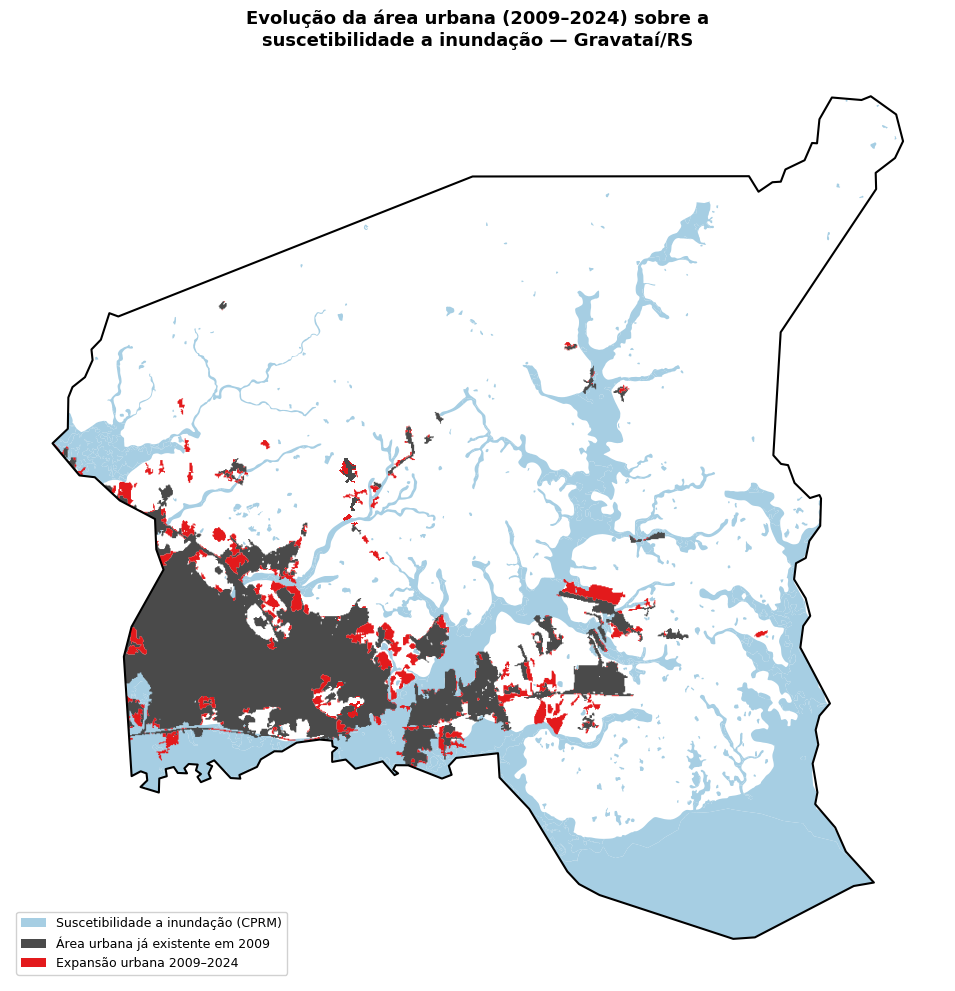

Figura A gerada.


In [11]:
# Figura A — Evolução da área urbana (2009-2024) sobre a suscetibilidade
fig, ax = plt.subplots(figsize=(10, 10))

gravatai_m.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.5, zorder=4)
suscetibilidade_recortada.plot(ax=ax, color="#a6cee3", edgecolor="none", zorder=1)
gdf_urbano_2009_m.plot(ax=ax, color="#4a4a4a", edgecolor="none", zorder=2)
expansao_urbana.plot(ax=ax, color="#e31a1c", edgecolor="none", zorder=3)

ax.set_title("Evolução da área urbana (2009–2024) sobre a\nsuscetibilidade a inundação — Gravataí/RS",
              fontsize=13, fontweight="bold")
ax.set_axis_off()

legend_elements_a = [
    Patch(facecolor="#a6cee3", label="Suscetibilidade a inundação (CPRM)"),
    Patch(facecolor="#4a4a4a", label="Área urbana já existente em 2009"),
    Patch(facecolor="#e31a1c", label="Expansão urbana 2009–2024"),
]
ax.legend(handles=legend_elements_a, loc="lower left", fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig("figura_evolucao_urbana_suscetibilidade.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figura A gerada.")


### Figura B — Área urbana atingida pela enchente de maio de 2024

Mesma lógica de cores sólidas da Figura A, agora mostrando a mancha real da enchente, a área urbana não atingida, e — em destaque — a interseção entre as duas, calculada na Etapa 6.

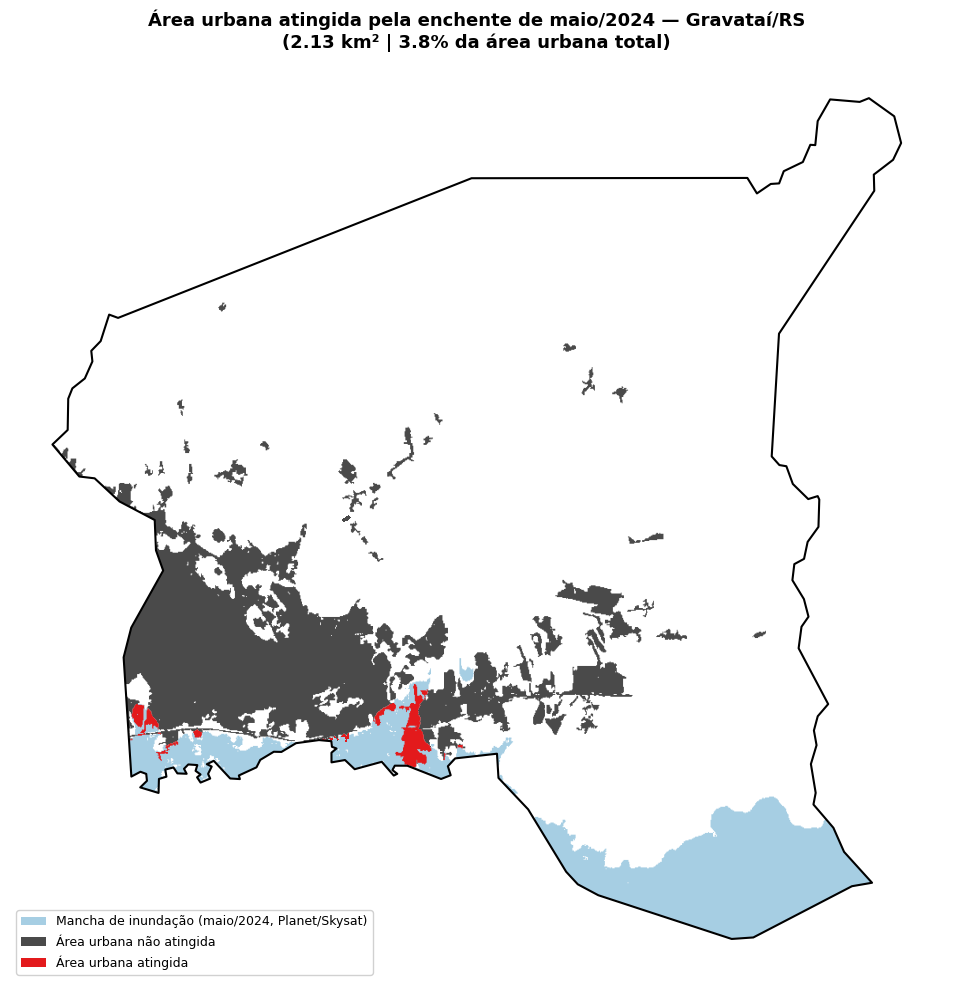

Figura B gerada.


In [12]:
# Figura B — Área urbana atingida pela enchente de maio/2024
fig, ax = plt.subplots(figsize=(10, 10))

gravatai_m.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.5, zorder=4)
mancha_planet_recortada.plot(ax=ax, color="#a6cee3", edgecolor="none", zorder=1)
urbano_nao_atingido_2024.plot(ax=ax, color="#4a4a4a", edgecolor="none", zorder=2)
intersecao_urbano_mancha_2024.plot(ax=ax, color="#e31a1c", edgecolor="none", zorder=3)

ax.set_title(f"Área urbana atingida pela enchente de maio/2024 — Gravataí/RS\n"
             f"({area_urbana_atingida_km2} km² | {pct_urbana_atingida}% da área urbana total)",
             fontsize=13, fontweight="bold")
ax.set_axis_off()

legend_elements_b = [
    Patch(facecolor="#a6cee3", label="Mancha de inundação (maio/2024, Planet/Skysat)"),
    Patch(facecolor="#4a4a4a", label="Área urbana não atingida"),
    Patch(facecolor="#e31a1c", label="Área urbana atingida"),
]
ax.legend(handles=legend_elements_b, loc="lower left", fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig("figura_area_urbana_atingida_enchente2024.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figura B gerada.")


### Figura C — Suscetibilidade teórica (CPRM/HAND) × mancha real

Comparo o que o modelo teórico da CPRM previa como suscetível com o que realmente alagou em maio de 2024. O resultado (99,6% de coincidência) foi mais alto do que eu esperava — praticamente toda a mancha real caiu dentro da área que o método HAND já apontava como suscetível, o que é um bom indício de que o modelo funciona bem pra esse recorte.

/usr/local/lib/python3.13/dist-packages/geopandas/tools/overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 38 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)
/usr/local/lib/python3.13/dist-packages/geopandas/tools/overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 26 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


Da mancha real de inundação: 37.34 km² (99.6%) caiu DENTRO da área prevista como suscetível pela CPRM
Da mancha real de inundação: 0.14 km² (0.4%) caiu FORA da área prevista (extrapolou o modelo teórico)


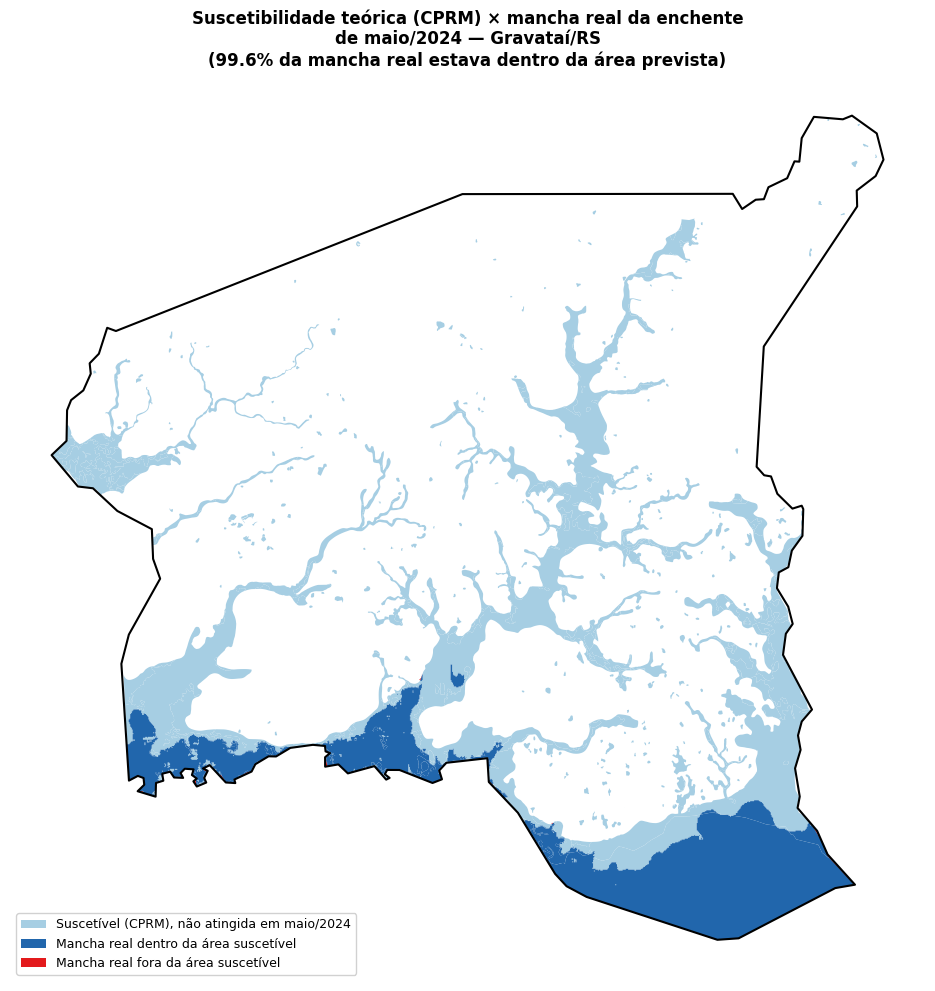

Figura C gerada.


In [13]:
# Categorias sem sobreposição de cor:
suscetivel_nao_atingida = gpd.overlay(suscetibilidade_recortada, mancha_planet_recortada, how="difference")
mancha_dentro_suscetibilidade = gpd.overlay(mancha_planet_recortada, suscetibilidade_recortada, how="intersection")
mancha_fora_suscetibilidade = gpd.overlay(mancha_planet_recortada, suscetibilidade_recortada, how="difference")

area_mancha_dentro_km2 = round(mancha_dentro_suscetibilidade.area.sum() / 1_000_000, 2)
area_mancha_fora_km2 = round(mancha_fora_suscetibilidade.area.sum() / 1_000_000, 2)
pct_mancha_dentro_suscetibilidade = round(100 * area_mancha_dentro_km2 / area_mancha_inundacao_km2, 1)
pct_mancha_fora_suscetibilidade = round(100 * area_mancha_fora_km2 / area_mancha_inundacao_km2, 1)

print(f"Da mancha real de inundação: {area_mancha_dentro_km2} km² ({pct_mancha_dentro_suscetibilidade}%) caiu DENTRO da área prevista como suscetível pela CPRM")
print(f"Da mancha real de inundação: {area_mancha_fora_km2} km² ({pct_mancha_fora_suscetibilidade}%) caiu FORA da área prevista (extrapolou o modelo teórico)")

fig, ax = plt.subplots(figsize=(10, 10))

gravatai_m.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.5, zorder=4)
suscetivel_nao_atingida.plot(ax=ax, color="#a6cee3", edgecolor="none", zorder=1)
mancha_dentro_suscetibilidade.plot(ax=ax, color="#2166ac", edgecolor="none", zorder=2)
mancha_fora_suscetibilidade.plot(ax=ax, color="#e31a1c", edgecolor="none", zorder=3)

ax.set_title(f"Suscetibilidade teórica (CPRM) × mancha real da enchente\nde maio/2024 — Gravataí/RS\n"
             f"({pct_mancha_dentro_suscetibilidade}% da mancha real estava dentro da área prevista)",
             fontsize=12, fontweight="bold")
ax.set_axis_off()

legend_elements_c = [
    Patch(facecolor="#a6cee3", label="Suscetível (CPRM), não atingida em maio/2024"),
    Patch(facecolor="#2166ac", label="Mancha real dentro da área suscetível"),
    Patch(facecolor="#e31a1c", label="Mancha real fora da área suscetível"),
]
ax.legend(handles=legend_elements_c, loc="lower left", fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig("figura_suscetibilidade_x_mancha_real.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figura C gerada.")


### Figura D — Expansão urbana × mancha real

Isolo só a área que virou urbana depois de 2009 (não a cidade inteira) e cruzo com a mancha real, pra ver se a ocupação mais recente foi proporcionalmente mais ou menos atingida do que a área urbana como um todo. O resultado (5,2%) ficou abaixo da proporção geral de suscetibilidade do município (23,7%), o que discuto no capítulo de resultados do TCC.

Área de expansão urbana total (2009-2024): 9.7 km²
Dessa expansão, 0.5 km² (5.2%) foi atingida pela enchente de maio/2024


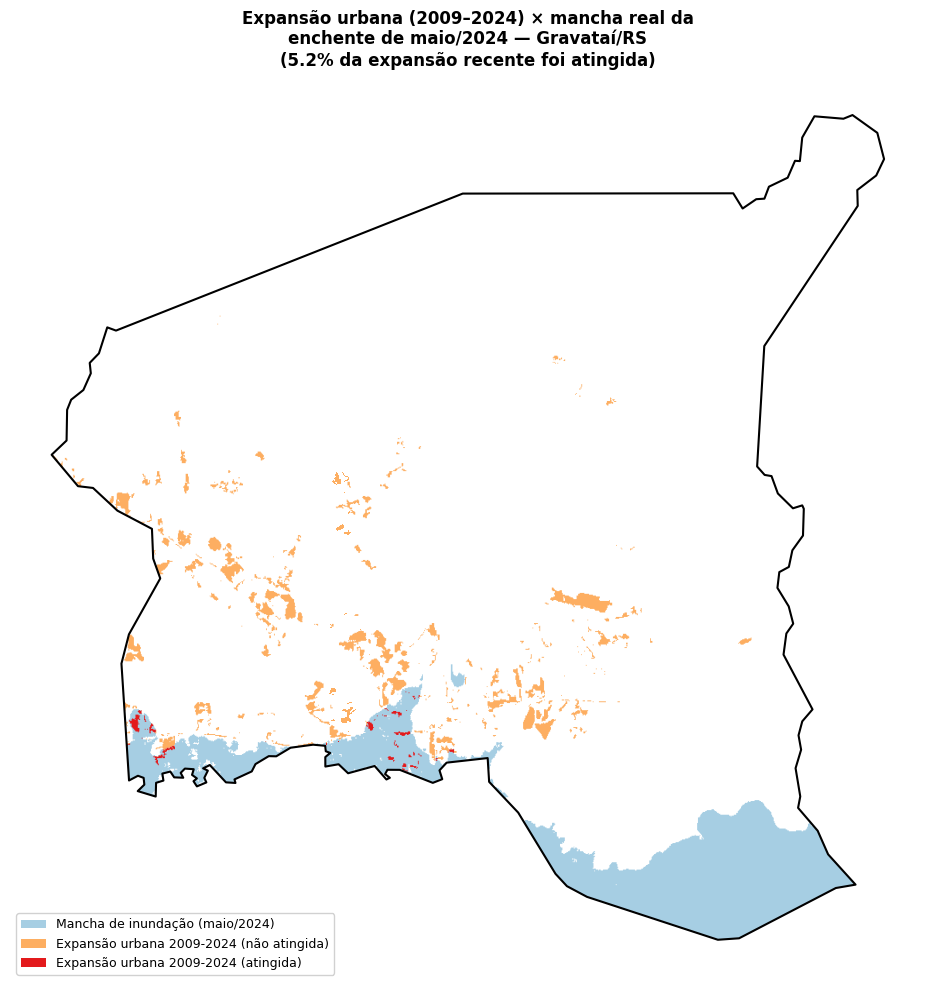

Figura D gerada.


In [14]:
expansao_atingida = gpd.overlay(expansao_urbana, mancha_planet_recortada, how="intersection")
expansao_nao_atingida = gpd.overlay(expansao_urbana, mancha_planet_recortada, how="difference")

area_expansao_total_km2 = round(expansao_urbana.area.sum() / 1_000_000, 2)
area_expansao_atingida_km2 = round(expansao_atingida.area.sum() / 1_000_000, 2)
pct_expansao_atingida = round(100 * area_expansao_atingida_km2 / area_expansao_total_km2, 1)

print(f"Área de expansão urbana total (2009-2024): {area_expansao_total_km2} km²")
print(f"Dessa expansão, {area_expansao_atingida_km2} km² ({pct_expansao_atingida}%) foi atingida pela enchente de maio/2024")

fig, ax = plt.subplots(figsize=(10, 10))

gravatai_m.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.5, zorder=4)
mancha_planet_recortada.plot(ax=ax, color="#a6cee3", edgecolor="none", zorder=1)
expansao_nao_atingida.plot(ax=ax, color="#fdae61", edgecolor="none", zorder=2)
expansao_atingida.plot(ax=ax, color="#e31a1c", edgecolor="none", zorder=3)

ax.set_title(f"Expansão urbana (2009–2024) × mancha real da\nenchente de maio/2024 — Gravataí/RS\n"
             f"({pct_expansao_atingida}% da expansão recente foi atingida)",
             fontsize=12, fontweight="bold")
ax.set_axis_off()

legend_elements_d = [
    Patch(facecolor="#a6cee3", label="Mancha de inundação (maio/2024)"),
    Patch(facecolor="#fdae61", label="Expansão urbana 2009-2024 (não atingida)"),
    Patch(facecolor="#e31a1c", label="Expansão urbana 2009-2024 (atingida)"),
]
ax.legend(handles=legend_elements_d, loc="lower left", fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig("figura_expansao_urbana_x_mancha_real.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figura D gerada.")


## Etapa 8 — Salvar tudo no Google Drive (se disponível)

Depois de perder processamento com a sessão caindo mais de uma vez, criei essa etapa pra guardar uma cópia de tudo: as 14 camadas em `.gpkg`, a tabela com os números do TCC em `.csv`, e as quatro figuras em `.png`, dentro de `resultados/` no Drive. Só roda de fato se `DRIVE_DISPONIVEL` for `True` (Etapa 0); caso contrário, essa célula só avisa que pulou o backup e segue em frente — as figuras continuam geradas normalmente na sessão, só não ficam salvas fora do Colab.

In [ ]:
if not DRIVE_DISPONIVEL:
    print("Drive não conectado nesta sessão — pulando o salvamento de backup (Etapa 8).")
    print("As figuras e os dados continuam disponíveis normalmente nesta sessão do Colab.")
else:
    # --- Camadas geoespaciais ---
    camadas_para_salvar = {
        "limite_gravatai.gpkg": gravatai_m,
        "suscetibilidade_recortada.gpkg": suscetibilidade_recortada,
        "urbano_2009.gpkg": gdf_urbano_2009_m,
        "urbano_2024.gpkg": gdf_urbano_2024_m,
        "expansao_urbana_2009_2024.gpkg": expansao_urbana,
        "mancha_inundacao_maio2024.gpkg": mancha_planet_recortada,
        "urbano_atingido_enchente2024.gpkg": intersecao_urbano_mancha_2024,
        "urbano_nao_atingido_enchente2024.gpkg": urbano_nao_atingido_2024,
        "urbano_sobre_suscetibilidade_2009.gpkg": intersecao_urbano_suscet_2009,
        "urbano_sobre_suscetibilidade_2024.gpkg": intersecao_urbano_suscet_2024,
        "mancha_dentro_suscetibilidade.gpkg": mancha_dentro_suscetibilidade,
        "mancha_fora_suscetibilidade.gpkg": mancha_fora_suscetibilidade,
        "expansao_urbana_atingida.gpkg": expansao_atingida,
        "expansao_urbana_nao_atingida.gpkg": expansao_nao_atingida,
    }

    for nome_arquivo, gdf in camadas_para_salvar.items():
        caminho = f"{PASTA_RESULTADOS}/{nome_arquivo}"
        gdf.to_file(caminho, driver="GPKG")
        print("Salvo:", nome_arquivo)

    # --- Tabela resumo com todos os números do TCC ---
    resumo = pd.DataFrame([
        {"indicador": "Área do município", "valor": area_municipio_km2, "unidade": "km²"},
        {"indicador": "Área suscetível a inundação (CPRM)", "valor": area_suscetibilidade_km2, "unidade": "km²"},
        {"indicador": "Área urbana 2009", "valor": area_urbana_2009_km2, "unidade": "km²"},
        {"indicador": "Área urbana 2024", "valor": area_urbana_2024_km2, "unidade": "km²"},
        {"indicador": "Crescimento urbano 2009-2024", "valor": crescimento_urbano_pct, "unidade": "%"},
        {"indicador": "Área urbana 2009 sobre planície suscetível", "valor": area_urbana_suscetivel_2009, "unidade": "km²"},
        {"indicador": "% da área urbana 2009 sobre planície suscetível", "valor": pct_urbana_suscetivel_2009, "unidade": "%"},
        {"indicador": "Área urbana 2024 sobre planície suscetível", "valor": area_urbana_suscetivel_2024, "unidade": "km²"},
        {"indicador": "% da área urbana 2024 sobre planície suscetível", "valor": pct_urbana_suscetivel_2024, "unidade": "%"},
        {"indicador": "Área da mancha de inundação real (maio/2024)", "valor": area_mancha_inundacao_km2, "unidade": "km²"},
        {"indicador": "Área urbana atingida pela enchente (maio/2024)", "valor": area_urbana_atingida_km2, "unidade": "km²"},
        {"indicador": "% da área urbana atingida pela enchente", "valor": pct_urbana_atingida, "unidade": "%"},
        {"indicador": "Mancha real dentro da área suscetível (CPRM)", "valor": area_mancha_dentro_km2, "unidade": "km²"},
        {"indicador": "% da mancha real dentro da área suscetível", "valor": pct_mancha_dentro_suscetibilidade, "unidade": "%"},
        {"indicador": "Mancha real fora da área suscetível (CPRM)", "valor": area_mancha_fora_km2, "unidade": "km²"},
        {"indicador": "% da mancha real fora da área suscetível", "valor": pct_mancha_fora_suscetibilidade, "unidade": "%"},
        {"indicador": "Expansão urbana total 2009-2024", "valor": area_expansao_total_km2, "unidade": "km²"},
        {"indicador": "Expansão urbana atingida pela enchente", "valor": area_expansao_atingida_km2, "unidade": "km²"},
        {"indicador": "% da expansão urbana atingida pela enchente", "valor": pct_expansao_atingida, "unidade": "%"},
    ])
    caminho_csv = f"{PASTA_RESULTADOS}/tabela_resumo_resultados.csv"
    resumo.to_csv(caminho_csv, index=False, encoding="utf-8-sig")
    print("\nSalvo: tabela_resumo_resultados.csv")
    print(resumo.to_string(index=False))

    # --- Figuras ---
    figuras = [
        "figura_evolucao_urbana_suscetibilidade.png",
        "figura_area_urbana_atingida_enchente2024.png",
        "figura_suscetibilidade_x_mancha_real.png",
        "figura_expansao_urbana_x_mancha_real.png",
    ]
    for nome_fig in figuras:
        shutil.copy(nome_fig, f"{PASTA_RESULTADOS}/{nome_fig}")
    print("\nFiguras copiadas para o Drive.")

    print("\n" + "="*60)
    print("TUDO SALVO em:", PASTA_RESULTADOS)
    print("="*60)


## Etapa 9 — Figuras de apresentação do TCC (Localização e Fluxograma)

As quatro figuras anteriores são as figuras de resultado. Mas o TCC também usa duas figuras de apresentação/metodologia — a Figura 1 (localização da área de estudo) e a Figura 2 (fluxograma das etapas metodológicas) — que na primeira versão do projeto eram um desenho esquemático feito à mão, sem geometria real. Refiz as duas aqui, com dados de verdade, pra manter o mesmo padrão de rigor do resto do trabalho.

### Figura 1 — Localização real da área de estudo

Uso o `geobr` pra buscar as camadas oficiais do IBGE: o contorno do Brasil, o estado do Rio Grande do Sul, e a Região Metropolitana de Porto Alegre (filtro a tabela de regiões metropolitanas pelo nome, já que o `geobr` não tem uma função específica só pra RMPA). O município de Gravataí eu já tenho — é o `gravatai_m` da Etapa 1, só precisei reprojetar pra EPSG:4326 pra bater com o resto das camadas nesse mapa. O resultado é um mapa de três painéis, cada um destacando a escala seguinte (Brasil → RS → RMPA), substituindo o desenho esquemático da primeira versão do projeto.

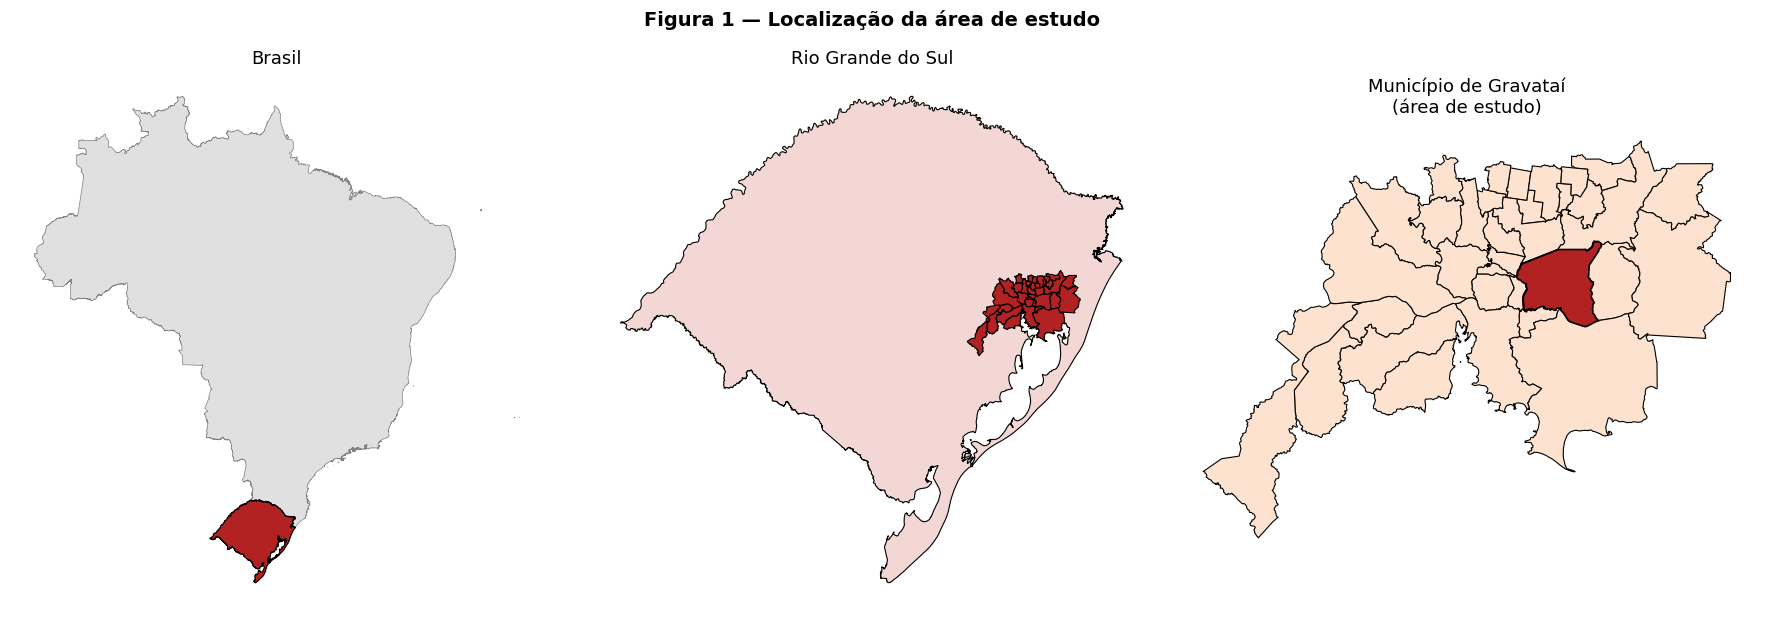

Figura 1 gerada com sucesso.


In [17]:
# Camada 1: Brasil inteiro
brasil = geobr.read_country(year=2020)

# Camada 2: Rio Grande do Sul
rs = geobr.read_state(code_state="RS", year=2020)

# Camada 3: Região Metropolitana de Porto Alegre (RMPA)
metro = geobr.read_metro_area(year=2018)
rmpa = metro[metro['name_metro'].str.contains("Porto Alegre", case=False, na=False)]

# Camada 4: Gravataí (já temos gravatai_m, só precisa reprojetar pra bater com as outras camadas)
gravatai_4326_plot = gravatai_m.to_crs("EPSG:4326")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Painel 1: Brasil com RS destacado
brasil.plot(ax=axes[0], color="#e0e0e0", edgecolor="gray", linewidth=0.5)
rs.plot(ax=axes[0], color="#b22222", edgecolor="black", linewidth=0.8)
axes[0].set_title("Brasil", fontsize=13)
axes[0].set_axis_off()

# Painel 2: RS com a RMPA destacada
rs.plot(ax=axes[1], color="#f2d7d5", edgecolor="black", linewidth=0.8)
rmpa.plot(ax=axes[1], color="#b22222", edgecolor="black", linewidth=0.8)
axes[1].set_title("Rio Grande do Sul", fontsize=13)
axes[1].set_axis_off()

# Painel 3: RMPA com Gravataí destacado
rmpa.plot(ax=axes[2], color="#fde3cf", edgecolor="black", linewidth=0.8)
gravatai_4326_plot.plot(ax=axes[2], color="#b22222", edgecolor="black", linewidth=1.2)
axes[2].set_title("Município de Gravataí\n(área de estudo)", fontsize=13)
axes[2].set_axis_off()

plt.suptitle("Figura 1 — Localização da área de estudo", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figura1_localizacao_real.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figura 1 gerada com sucesso.")

In [ ]:
from google.colab import files

files.download("figura1_localizacao_real.png")
if DRIVE_DISPONIVEL:
    shutil.copy("figura1_localizacao_real.png", f"{PASTA_RESULTADOS}/figura1_localizacao_real.png")
    print("Figura 1 baixada e salva no Drive.")
else:
    print("Figura 1 baixada (backup no Drive pulado, sessão sem Drive conectado).")


### Figura 2 — Fluxograma das etapas metodológicas (sem QGIS)

O fluxograma original tinha uma caixa citando o QGIS como ferramenta de sobreposição das camadas — mas como troquei o QGIS pelo processamento em Python/Colab (nota da seção 3.4 do TCC), refiz essa figura do zero, com as mesmas 8 etapas, só ajustando o texto da caixa 6. Desenhei o fluxograma manualmente com `matplotlib.patches` (retângulos arredondados e setas), em vez de usar uma ferramenta externa de diagramação, pra manter tudo dentro do mesmo notebook.

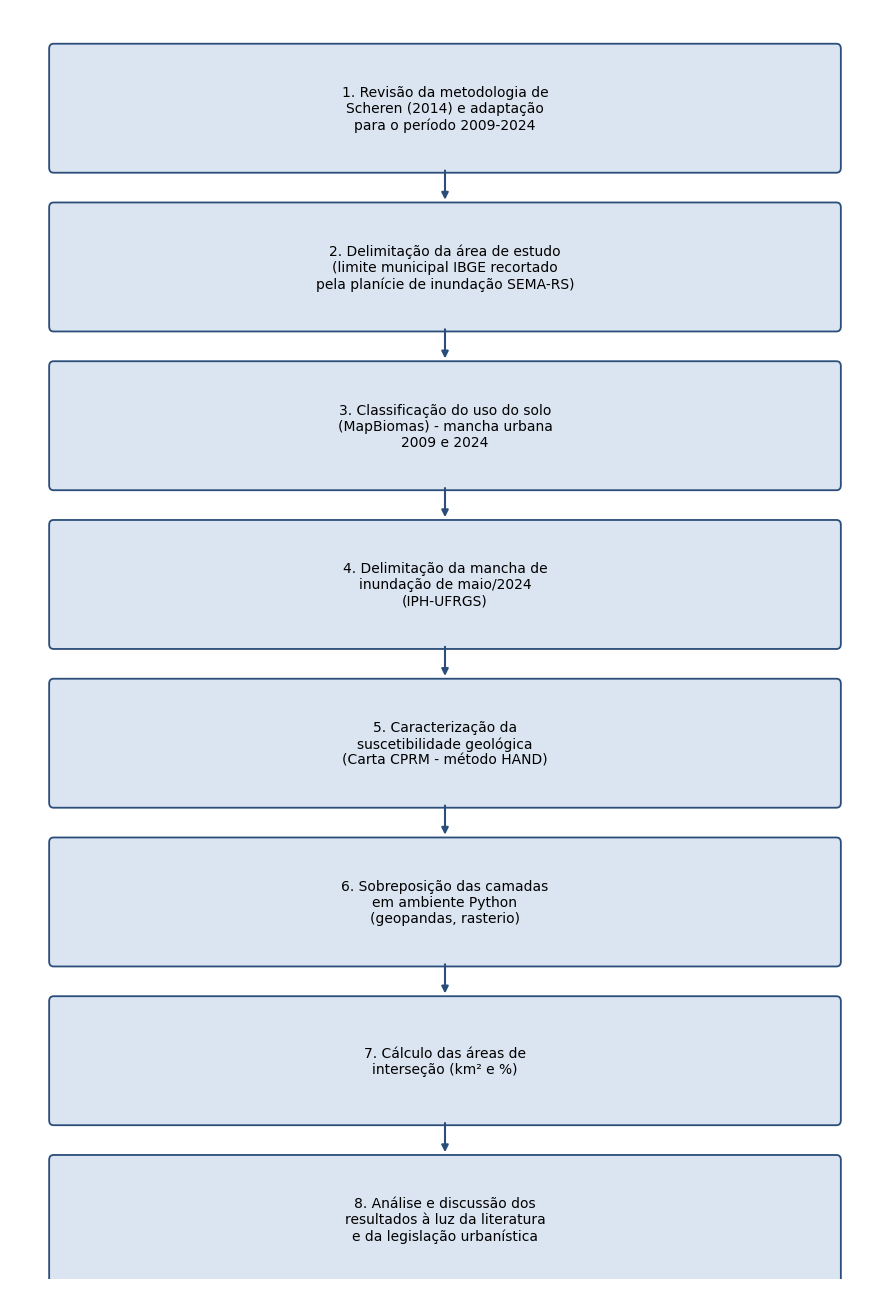

Figura 2 regenerada sem menção ao QGIS.


In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

etapas = [
    "1. Revisão da metodologia de\nScheren (2014) e adaptação\npara o período 2009-2024",
    "2. Delimitação da área de estudo\n(limite municipal IBGE recortado\npela planície de inundação SEMA-RS)",
    "3. Classificação do uso do solo\n(MapBiomas) - mancha urbana\n2009 e 2024",
    "4. Delimitação da mancha de\ninundação de maio/2024\n(IPH-UFRGS)",
    "5. Caracterização da\nsuscetibilidade geológica\n(Carta CPRM - método HAND)",
    "6. Sobreposição das camadas\nem ambiente Python\n(geopandas, rasterio)",
    "7. Cálculo das áreas de\ninterseção (km² e %)",
    "8. Análise e discussão dos\nresultados à luz da literatura\ne da legislação urbanística",
]

fig, ax = plt.subplots(figsize=(9, 13))
ax.set_xlim(0, 10)
ax.set_ylim(0, len(etapas) * 1.6)
ax.axis("off")

box_height = 1.2
gap = 0.4
for i, texto in enumerate(etapas):
    y = (len(etapas) - 1 - i) * (box_height + gap)
    box = mpatches.FancyBboxPatch((0.5, y), 9, box_height,
                                    boxstyle="round,pad=0.05,rounding_size=0.05",
                                    facecolor="#dbe5f1", edgecolor="#2a4d7a", linewidth=1.3)
    ax.add_patch(box)
    ax.text(5, y + box_height / 2, texto, ha="center", va="center", fontsize=10)
    if i < len(etapas) - 1:
        y_arrow_start = y
        y_arrow_end = y - gap
        ax.annotate("", xy=(5, y_arrow_end + 0.05), xytext=(5, y_arrow_start),
                    arrowprops=dict(arrowstyle="-|>", color="#2a4d7a", linewidth=1.5))

plt.tight_layout()
plt.savefig("figura2_fluxograma_atualizado.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figura 2 regenerada sem menção ao QGIS.")

In [ ]:
from google.colab import files

files.download("figura2_fluxograma_atualizado.png")
if DRIVE_DISPONIVEL:
    shutil.copy("figura2_fluxograma_atualizado.png", f"{PASTA_RESULTADOS}/figura2_fluxograma_atualizado.png")
    print("Figura 2 baixada e salva no Drive.")
else:
    print("Figura 2 baixada (backup no Drive pulado, sessão sem Drive conectado).")


---
### Notas de continuidade

- Este notebook é autossuficiente: rodando `Executar tudo` do início, ele reconstrói todas as variáveis e regrava os resultados no Drive, sem gerar duplicata.
- Nenhum arquivo precisa estar pré-salvo em lugar nenhum — todos os dados de entrada (IBGE, MapBiomas, CPRM, Zenodo) são baixados automaticamente pela internet.
- Os arquivos em `TCC_Gravatai_Dados/resultados/` podem ser conferidos a qualquer momento, mesmo fora do Colab (os `.gpkg` abrem no QGIS, o `.csv` abre no Excel/Sheets, os `.png` são as figuras finais usadas no TCC).
- Este notebook está referenciado no corpo do TCC como material suplementar, com o código-fonte disponível publicamente no repositório indicado no início deste documento.